In [81]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, FixedLocator
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MultipleLocator
from matplotlib.font_manager import FontProperties
import matplotlib.font_manager as fm

import warnings
warnings.filterwarnings("ignore")

In [82]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 9
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

font_path = os.path.join('..', 'other', 'Roboto', 'Roboto-Regular.ttf')
font_prop = FontProperties(fname = font_path)
fm.fontManager.addfont(font_path)
custom_font_name = font_prop.get_name()

font_path_bold = os.path.join('..', 'other', 'Roboto', 'Roboto-Bold.ttf')
font_prop_bold = FontProperties(fname = font_path_bold)

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8})
plt.rcParams['font.family'] = custom_font_name
plt.rcParams['axes.unicode_minus'] = True

In [83]:
results_file = 'overall_nitrous_oxide_vs_hydrogen_peroxide.xlsx'

In [84]:
economics_df_per_kmol = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'economics_per_kmol', index_col = 0)
economics_df_per_kmol_final = economics_df_per_kmol.drop(columns = ['Total', 'Impact 2050'])
economics_df_per_kmol_final

,Scenario,Ammonia,Hydrogen,2-Ethylanthraquinone,Electricity,Heating,Cooling,CAPEX,Direct emissions
0,N2O,29.465173,0.000000,0.000000,0.249909,0.000000,4.436975,1.598514,0
1,H2O2,0.000000,4.134295,59.616386,0.281359,0.476419,0.048595,1.240246,0
2,N2O,55.275979,0.000000,0.000000,0.249909,0.000000,4.436975,1.598514,0
3,H2O2,0.000000,13.903737,59.616386,0.281359,0.476419,0.048595,1.240246,0


In [85]:
economics_df_per_kg = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'economics_per_kg', index_col = 0)
economics_df_per_kg_final = economics_df_per_kg.drop(columns = ['Total', 'Impact 2050'])
economics_df_per_kg_final

,Scenario,Ammonia,Hydrogen,2-Ethylanthraquinone,Electricity,Heating,Cooling,CAPEX,Direct emissions
0,N2O,0.669663,0.000000,0.000000,0.005680,0.000000,0.100840,0.036330,0
1,H2O2,0.000000,0.121597,1.753423,0.008275,0.014012,0.001429,0.036478,0
2,N2O,1.256272,0.000000,0.000000,0.005680,0.000000,0.100840,0.036330,0
3,H2O2,0.000000,0.408933,1.753423,0.008275,0.014012,0.001429,0.036478,0


In [86]:
climate_change_df_per_kmol = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'climate_change_per_kmol', index_col = 0)
climate_change_df_per_kmol_final = climate_change_df_per_kmol.drop(columns = ['Total', 'Impact 2050'])
climate_change_df_per_kmol_final

,Scenario,Ammonia,Hydrogen,2-Ethylanthraquinone,Electricity,Heating,Cooling,CAPEX,Direct emissions
0,N2O,145.008660,0.000000,0.000000,1.965175,0.000000,47.393806,0,0.182282
1,H2O2,0.000000,31.756842,2.434067,2.042885,4.670283,0.044019,0,2.765141
2,N2O,34.688036,0.000000,0.000000,1.965175,0.000000,47.393806,0,0.182282
3,H2O2,0.000000,4.778452,2.434067,2.042885,4.670283,0.044019,0,2.765141


In [87]:
climate_change_df_per_kg = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'climate_change_per_kg', index_col = 0)
climate_change_df_per_kg_final = climate_change_df_per_kg.drop(columns = ['Total', 'Impact 2050'])
climate_change_df_per_kg_final

,Scenario,Ammonia,Hydrogen,2-Ethylanthraquinone,Electricity,Heating,Cooling,CAPEX,Direct emissions
0,N2O,3.295651,0.000000,0.00000,0.044663,0.000000,1.077132,0,0.004143
1,H2O2,0.000000,0.934025,0.07159,0.060085,0.137361,0.001295,0,0.081328
2,N2O,0.788364,0.000000,0.00000,0.044663,0.000000,1.077132,0,0.004143
3,H2O2,0.000000,0.140543,0.07159,0.060085,0.137361,0.001295,0,0.081328


In [88]:
x_pts = np.arange(0, len(climate_change_df_per_kmol_final))
x_labels = ['N$_\mathdefault{2}$O', 'H$_\mathdefault{2}$O$_\mathdefault{2}$'] * 2

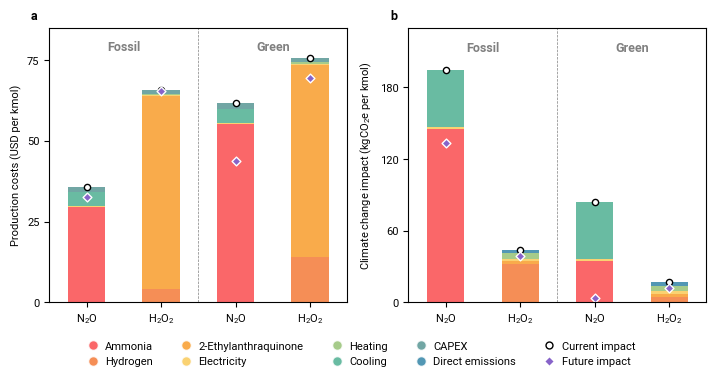

In [89]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize = (fig_length[2], fig_height*0.35))

colors = ['#f94144', '#f3722c', '#f8961e', '#f9c74f', '#90be6d', '#43aa8b', '#4d908e', '#277da1'] 

climate_change_df_per_kmol_final.plot(kind = 'bar', stacked = True, ax = ax2, color = colors, alpha = 0.8)
ax2.legend([], frameon = False)
ax2.set_ylabel('Climate change impact (kgCO$_\mathdefault{2}$e per kmol)')
ax2.set_xticks(x_pts)  
ax2.set_xticklabels(x_labels, rotation = 0, ha = 'center')  
ax2.scatter(x_pts, climate_change_df_per_kmol['Total'], s = 20, facecolor = 'white', edgecolors = '#000000')
ax2.scatter(x_pts, climate_change_df_per_kmol['Impact 2050'], s = 20, facecolor = '#8763c9', edgecolors = '#ffffff', marker = 'D', zorder = 1)
ax2.set_title('b', fontproperties = font_prop_bold, x = -0.05, fontsize = fontsize_title)
ax2.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5, zorder = 0)
ax2.axvline(x = 1.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax2.set_ylim([0, 230])
ax2.text(0.5, 210, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
ax2.text(2.5, 210, 'Green', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
ax2.yaxis.set_major_locator(MaxNLocator(4))
ax2.set_xticks(x_pts)  
ax2.set_xticklabels(x_labels, rotation = 0, ha = 'center')  

economics_df_per_kmol_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors, alpha = 0.8)
ax1.legend([], frameon = False)
ax1.set_ylabel('Production costs (USD per kmol)')
ax1.scatter(x_pts, economics_df_per_kmol['Total'], s = 20, facecolor = 'white', edgecolors = '#000000')
ax1.scatter(x_pts, economics_df_per_kmol['Impact 2050'], s = 20, facecolor = '#8763c9', edgecolors = '#ffffff', marker = 'D', zorder = 1)
ax1.set_title('a', fontproperties = font_prop_bold, x = -0.05, fontsize = fontsize_title)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
ax1.axvline(x = 1.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax1.set_ylim([0.0, 85])
ax1.text(0.5, 78, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
ax1.text(2.5, 78, 'Green', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
ax1.yaxis.set_major_locator(MaxNLocator(4))
ax1.set_xticks(x_pts)  
ax1.set_xticklabels(x_labels, rotation = 0, ha = 'center')  

labels = ['Ammonia', 'Hydrogen', '2-Ethylanthraquinone', 'Electricity', 'Heating', 'Cooling', 'CAPEX', 'Direct emissions', 'Current impact', 'Future impact']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 7, alpha = 0.8) for color in colors]
handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 5, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#8763c9', markersize = 5, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 5, frameon = False, handletextpad = 0.1)

filepath = os.path.join('..', 'plots', 'main_figure_current_future_per_kmol')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 1200)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 1200)

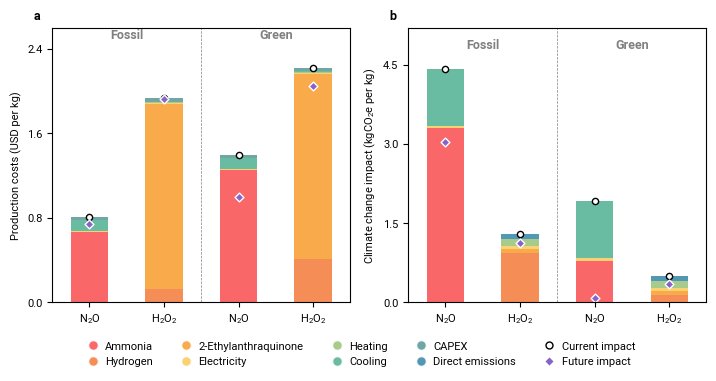

In [90]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize = (fig_length[2], fig_height*0.35))

colors = ['#f94144', '#f3722c', '#f8961e', '#f9c74f', '#90be6d', '#43aa8b', '#4d908e', '#277da1'] 

climate_change_df_per_kg_final.plot(kind = 'bar', stacked = True, ax = ax2, color = colors, alpha = 0.8)
ax2.legend([], frameon = False)
ax2.set_ylabel('Climate change impact (kgCO$_\mathdefault{2}$e per kg)')
ax2.set_xticks(x_pts)  
ax2.set_xticklabels(x_labels, rotation = 0, ha = 'center')  
ax2.scatter(x_pts, climate_change_df_per_kg['Total'], s = 20, facecolor = 'white', edgecolors = '#000000')
ax2.scatter(x_pts, climate_change_df_per_kg['Impact 2050'], s = 20, facecolor = '#8763c9', edgecolors = '#ffffff', marker = 'D', zorder = 1)
ax2.set_title('b', fontproperties = font_prop_bold, x = -0.05, fontsize = fontsize_title)
ax2.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5, zorder = 0)
ax2.axvline(x = 1.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax2.set_ylim([0, 5.2])
ax2.text(0.5, 4.8, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
ax2.text(2.5, 4.8, 'Green', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
ax2.yaxis.set_major_locator(MaxNLocator(4))
ax2.set_xticks(x_pts)  
ax2.set_xticklabels(x_labels, rotation = 0, ha = 'center')  

economics_df_per_kg_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors, alpha = 0.8)
ax1.legend([], frameon = False)
ax1.set_ylabel('Production costs (USD per kg)')
ax1.scatter(x_pts, economics_df_per_kg['Total'], s = 20, facecolor = 'white', edgecolors = '#000000')
ax1.scatter(x_pts, economics_df_per_kg['Impact 2050'], s = 20, facecolor = '#8763c9', edgecolors = '#ffffff', marker = 'D', zorder = 1)
ax1.set_title('a', fontproperties = font_prop_bold, x = -0.05, fontsize = fontsize_title)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
ax1.axvline(x = 1.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax1.set_ylim([0.0, 2.6])
ax1.text(0.5, 2.5, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
ax1.text(2.5, 2.5, 'Green', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
ax1.yaxis.set_major_locator(MaxNLocator(4))
ax1.set_xticks(x_pts)  
ax1.set_xticklabels(x_labels, rotation = 0, ha = 'center')

labels = ['Ammonia', 'Hydrogen', '2-Ethylanthraquinone', 'Electricity', 'Heating', 'Cooling', 'CAPEX', 'Direct emissions', 'Current impact', 'Future impact']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 7, alpha = 0.8) for color in colors]
handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 5, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#8763c9', markersize = 5, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 5, frameon = False, handletextpad = 0.1)

filepath = os.path.join('..', 'plots', 'main_figure_current_future_per_kg')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 1200)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 1200)